In [1]:
!pip install SoccerNet --upgrade
!pip install ultralytics opencv-python lap matplotlib
!pip install deep_sort_realtime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.9/86.9 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.7/67.7 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 88.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.5/14.5 MB 103.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 80.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 95.9 MB/s eta 0:00:00


In [2]:
import glob
from pathlib import Path
import matplotlib.pyplot as plt
import cv2
import numpy as np
from collections import defaultdict
from ultralytics import YOLO
from IPython.display import Video
from SoccerNet.Downloader import SoccerNetDownloader
from deep_sort_realtime.deepsort_tracker import DeepSort
import os
import math

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

project_path = "/content/SoccerNet"
game_id = "england_epl/2014-2015/2015-02-21 - 18-00 Chelsea 1 - 1 Burnley"
downloader = SoccerNetDownloader(LocalDirectory=project_path)
downloader.password = "s0cc3rn3t"

# Descargar solo los videos del partido
downloader.downloadGame(game=game_id, files=["1_720p.mkv"], spl="train")


Mounted at /content/drive


In [4]:
import torch
# Get cpu, gpu or mps device for training.
device = (
   "cuda"
   if torch.cuda.is_available()
   else "mps"
   if torch.backends.mps.is_available()
   else "cpu"
)

# device = "cpu"

print(f"Usando como dispositivo {device}")

Usando como dispositivo cuda


In [5]:
video_path = Path(project_path) / "england_epl/2014-2015/2015-02-21 - 18-00 Chelsea 1 - 1 Burnley" / "1_720p.mkv"

In [10]:
clips_output_dir = Path("/content/drive/MyDrive/clips")
clips_output_dir.mkdir(parents=True, exist_ok=True)

model = YOLO("yolov8l.pt")

# Detector
tracker = DeepSort(
    max_age=70,
    n_init=3,
    max_cosine_distance=0.15,
    max_iou_distance=0.7,
    nn_budget=300
)

ball_traces = {}

cap = cv2.VideoCapture(str(video_path))
fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fourcc = cv2.VideoWriter_fourcc(*"mp4v")

det_width = 1280
det_height = 720

num_parts = 60
frames_per_part = math.ceil(total_frames / num_parts)
cap.release()

# Deteccion jugadores en un espacio de frames
def smooth_trace(trace, window=3):
    if len(trace) < window:
        return trace
    smoothed = []
    for i in range(len(trace)):
        start = max(0, i - window + 1)
        xs = [p[0] for p in trace[start:i+1]]
        ys = [p[1] for p in trace[start:i+1]]
        smoothed.append((int(np.mean(xs)), int(np.mean(ys))))
    return smoothed

def process_clip_index(clip_idx):
    global ball_traces

    start_frame = clip_idx * frames_per_part
    end_frame = min((clip_idx + 1) * frames_per_part, total_frames)
    print(f"Procesando clip {clip_idx}: frames {start_frame} a {end_frame}")

    cap = cv2.VideoCapture(str(video_path))
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

    clip_path = clips_output_dir / f"clip_{clip_idx}.mp4"
    out = cv2.VideoWriter(str(clip_path), fourcc, fps, (width, height))

    max_area_limit = width * height * 0.18

    last_ball_pos = None
    predicted_ball_pos = None
    ball_missing_frames = 0
    max_missing = 8
    player_grace = 2

    # Listas para guardar detecciones por frame
    ball_counts = []
    player_counts = []

    for frame_idx in range(start_frame, end_frame):
        ret, frame = cap.read()
        if not ret:
            break

        frame_resized = cv2.resize(frame, (det_width, det_height))
        results = model(frame_resized)[0]
        detections = []

        x_scale = width / det_width
        y_scale = height / det_height

        # conteos temporales por frame
        num_balls = 0
        num_players = 0

        for r, cls in zip(results.boxes, results.boxes.cls):
            cls = int(cls)
            conf = float(r.conf[0])

            x1, y1, x2, y2 = map(int, r.xyxy[0])
            x1 = int(x1 * x_scale)
            y1 = int(y1 * y_scale)
            x2 = int(x2 * x_scale)
            y2 = int(y2 * y_scale)
            w, h = x2 - x1, y2 - y1
            area = w * h
            if area > max_area_limit:
                continue

            # Jugador
            if cls == 0:
                if w < 25 or h < 50 or w > 120 or h > 300:
                    continue
                aspect = h / (w + 1e-5)
                if aspect < 1.4 or aspect > 5.0:
                    continue

            # Balón
            if cls == 32:
                if w*h < 35 or w*h > 850:
                    continue
                ratio = w / (h + 1e-5)
                if ratio < 0.8 or ratio > 1.25:
                    continue

            detections.append(([x1, y1, w, h], conf, cls))

        tracks = tracker.update_tracks(detections, frame=frame)

        ball_detected = False
        current_ball_pos = None

        for t in tracks:
            if not t.is_confirmed():
                continue
            if t.time_since_update > player_grace:
                continue

            l, t_, r, b = map(int, t.to_ltrb())
            cls = t.det_class
            cx, cy = (l+r)//2, (t_+b)//2

            # Balón
            if cls == 32:
                num_balls += 1  # ← CONTADOR
                ball_detected = True
                current_ball_pos = (cx, cy)
                last_ball_pos = current_ball_pos
                ball_missing_frames = 0

                if predicted_ball_pos is not None:
                    px, py = predicted_ball_pos
                    cx = int(0.7*cx + 0.3*px)
                    cy = int(0.7*cy + 0.3*py)
                    current_ball_pos = (cx, cy)
                    last_ball_pos = current_ball_pos

                ball_traces.setdefault(0, []).append(current_ball_pos)

                cv2.rectangle(frame, (l, t_), (r, b), (0,255,255), 2)
                cv2.putText(frame, "Balon", (l, t_-5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,255), 2)

            # Jugador
            elif cls == 0:
                num_players += 1  # ← CONTADOR
                cv2.rectangle(frame, (l,t_), (r,b), (0,255,0), 2)
                cv2.putText(frame, "Jugador", (l, t_-5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 2)

        # guardar conteos por frame
        ball_counts.append(num_balls)
        player_counts.append(num_players)

        if not ball_detected and last_ball_pos is not None:
            ball_missing_frames += 1
            if ball_missing_frames <= max_missing:
                if predicted_ball_pos is None:
                    predicted_ball_pos = last_ball_pos
                else:
                    px, py = predicted_ball_pos
                    lx, ly = last_ball_pos
                    predicted_ball_pos = (int(px + 0.5*(lx-px)),
                                          int(py + 0.5*(ly-py)))

                x, y = predicted_ball_pos
                cv2.rectangle(frame, (x-10, y-10), (x+10, y+10), (0,255,255), 2)
                cv2.putText(frame, "Balon", (x-10, y-15),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,255), 2)

        if ball_detected:
            predicted_ball_pos = current_ball_pos

        out.write(frame)

    cap.release()
    out.release()
    print(f"Clip {clip_idx} guardado en {clip_path}")

    plt.figure(figsize=(12, 5))
    plt.plot(ball_counts, label="Detecciones de balón", color="orange")
    plt.plot(player_counts, label="Detecciones de jugadores", color="green")
    plt.title(f"Detecciones por frame - Clip {clip_idx}")
    plt.xlabel("Frame relativo en el clip")
    plt.ylabel("Cantidad de detecciones")
    plt.legend()
    plt.grid(True)

    plot_path = clips_output_dir / f"detecciones_clip_{clip_idx}.png"
    plt.savefig(plot_path)
    plt.show()
    plt.close()

    print(f"Gráfica guardada en {plot_path}")

Procesando clip 35: frames 39375 a 40500

0: 384x640 15 persons, 38.0ms
Speed: 1.9ms preprocess, 38.0ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 15 persons, 35.3ms
Speed: 2.0ms preprocess, 35.3ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 15 persons, 35.3ms
Speed: 2.9ms preprocess, 35.3ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 15 persons, 25.7ms
Speed: 2.0ms preprocess, 25.7ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 15 persons, 25.2ms
Speed: 2.4ms preprocess, 25.2ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 15 persons, 25.2ms
Speed: 2.0ms preprocess, 25.2ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 15 persons, 22.8ms
Speed: 2.0ms preprocess, 22.8ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 14 persons, 22.5ms
Speed: 2.0ms preprocess, 22.5ms 

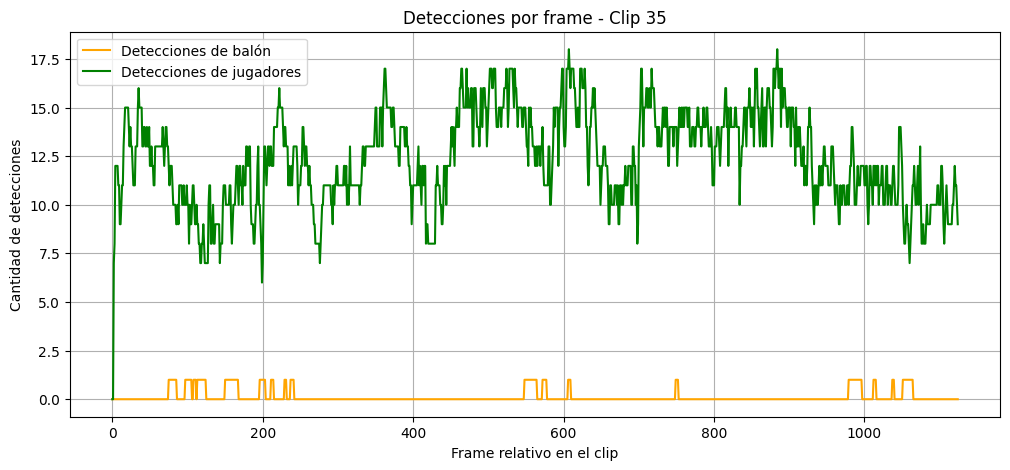

Gráfica guardada en /content/drive/MyDrive/clips/detecciones_clip_35.png


In [11]:
process_clip_index(35)

Procesando clip 25: frames 28125 a 29250

0: 384x640 3 persons, 1 sports ball, 40.0ms
Speed: 2.5ms preprocess, 40.0ms inference, 2.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 persons, 1 sports ball, 1 baseball glove, 39.9ms
Speed: 2.3ms preprocess, 39.9ms inference, 1.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 persons, 1 sports ball, 39.0ms
Speed: 5.3ms preprocess, 39.0ms inference, 1.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 persons, 1 sports ball, 38.2ms
Speed: 3.2ms preprocess, 38.2ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 persons, 1 sports ball, 35.8ms
Speed: 5.6ms preprocess, 35.8ms inference, 3.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 persons, 1 sports ball, 34.0ms
Speed: 4.4ms preprocess, 34.0ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 persons, 1 sports ball, 34.0ms
Speed: 1.9ms preprocess, 34.0ms inference, 1

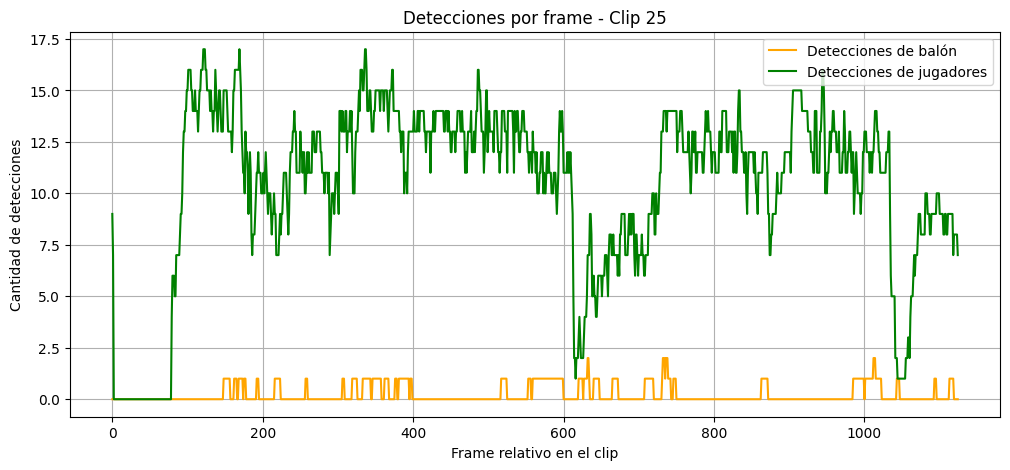

Gráfica guardada en /content/drive/MyDrive/clips/detecciones_clip_25.png


In [12]:
process_clip_index(25)

Procesando clip 15: frames 16875 a 18000

0: 384x640 19 persons, 40.0ms
Speed: 2.3ms preprocess, 40.0ms inference, 2.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 18 persons, 42.8ms
Speed: 6.9ms preprocess, 42.8ms inference, 3.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 17 persons, 39.9ms
Speed: 6.9ms preprocess, 39.9ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 18 persons, 45.1ms
Speed: 8.7ms preprocess, 45.1ms inference, 3.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 17 persons, 1 sports ball, 39.9ms
Speed: 4.4ms preprocess, 39.9ms inference, 1.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 19 persons, 35.3ms
Speed: 2.3ms preprocess, 35.3ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 19 persons, 1 sports ball, 37.1ms
Speed: 2.0ms preprocess, 37.1ms inference, 1.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 18 persons, 1 sports 

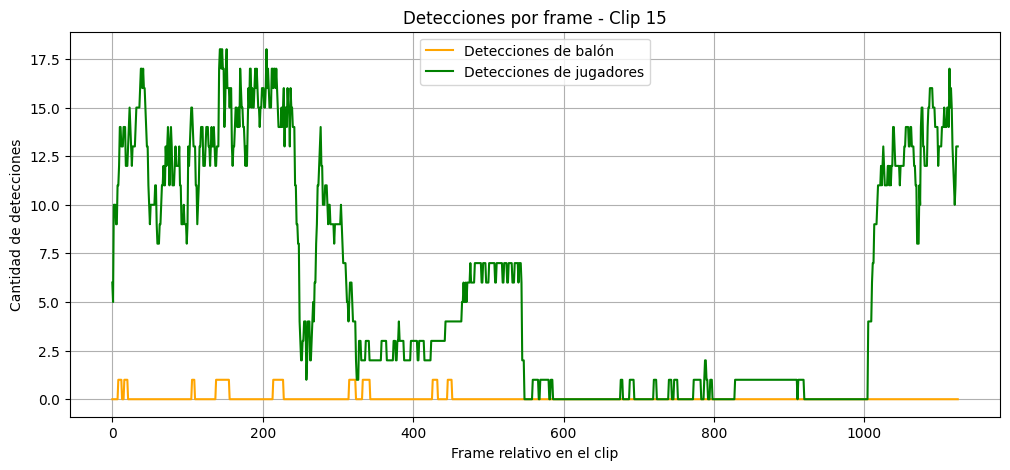

Gráfica guardada en /content/drive/MyDrive/clips/detecciones_clip_15.png


In [13]:
process_clip_index(15)